In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.dropna(subset=['RainTomorrow'],inplace=True)

In [4]:
year = pd.to_datetime(df.Date).dt.year

<Axes: title={'center': 'year'}, xlabel='Date', ylabel='count'>

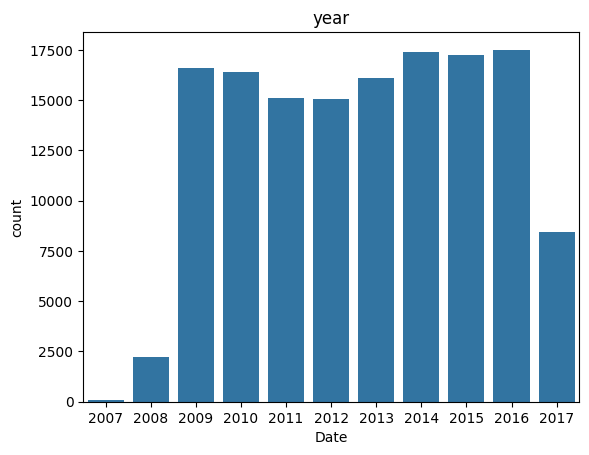

In [5]:
plt.title('year')
sns.countplot(x=pd.to_datetime(df.Date).dt.year)

In [6]:
train_df=df[year<2015]
val_df=df[year==2015]
test_df=df[year>2015]

In [7]:
test_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
2498,2016-01-01,Albury,20.4,37.6,0.0,NaN,NaN,ENE,54.0,NaN,...,46.0,17.0,1013.4,1009.2,7.0,3.0,26.1,36.7,No,No
2499,2016-01-02,Albury,20.9,33.6,0.4,NaN,NaN,SSE,50.0,SSE,...,54.0,30.0,1011.1,1008.4,8.0,8.0,24.8,31.7,No,Yes
2500,2016-01-03,Albury,18.4,23.1,2.2,NaN,NaN,ENE,48.0,ESE,...,62.0,67.0,1014.0,1014.8,8.0,8.0,21.8,19.5,Yes,Yes
2501,2016-01-04,Albury,17.3,23.7,15.6,NaN,NaN,SSE,39.0,SE,...,74.0,65.0,1017.9,1016.5,8.0,8.0,19.2,21.6,Yes,Yes
2502,2016-01-05,Albury,15.5,22.9,6.8,NaN,NaN,ENE,31.0,SE,...,92.0,63.0,1016.3,1013.9,8.0,8.0,17.2,22.2,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,...,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


In [8]:
input_cols=list(train_df.columns)[1:-1]
target_col = 'RainTomorrow'
input_cols

['Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday']

In [9]:
train_input = train_df[input_cols].copy()
train_target = train_df[target_col].copy()

val_input = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

test_input = test_df[input_cols].copy()
test_target = test_df[target_col].copy()

In [10]:
train_input

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,Uluru,16.9,33.2,0.0,NaN,NaN,SSE,43.0,ESE,SSE,...,26.0,22.0,13.0,1014.1,1009.8,NaN,NaN,23.7,31.8,No
144549,Uluru,15.1,36.8,0.0,NaN,NaN,NE,31.0,ENE,SW,...,20.0,16.0,8.0,1012.6,1007.6,NaN,NaN,28.9,34.8,No
144550,Uluru,17.3,37.8,0.0,NaN,NaN,ESE,39.0,ESE,SSE,...,9.0,15.0,8.0,1011.9,1008.0,NaN,NaN,29.7,35.7,No
144551,Uluru,20.1,38.5,0.0,NaN,NaN,ESE,43.0,ESE,SSW,...,17.0,22.0,9.0,1014.0,1009.2,NaN,NaN,29.8,37.2,No


In [11]:
numeric_cols =train_input.select_dtypes(include=np.number).columns.tolist()
categorical_cols=train_input.select_dtypes('object').columns.tolist()
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [12]:
from sklearn.impute import SimpleImputer

In [13]:
imputer=SimpleImputer(strategy='mean')

In [14]:
imputer.fit(df[numeric_cols])

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [15]:
train_input[numeric_cols] = imputer.transform(train_input[numeric_cols])
val_input[numeric_cols] = imputer.transform(val_input[numeric_cols])
test_input[numeric_cols] = imputer.transform(test_input[numeric_cols])

In [16]:
test_input[numeric_cols].isna().sum().sum()

np.int64(0)

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler=MinMaxScaler()

In [19]:
scaler.fit(df[numeric_cols])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [20]:
train_input[numeric_cols]= scaler.fit_transform(train_input[numeric_cols])
val_input[numeric_cols]= scaler.fit_transform(val_input[numeric_cols])
test_input[numeric_cols]= scaler.fit_transform(test_input[numeric_cols])
train_input[numeric_cols]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,0.516509,0.517241,0.001617,0.066381,0.533207,0.294574,0.229885,0.275862,0.71,0.22,0.449587,0.463696,0.888889,0.500352,0.494577,0.525391
1,0.375000,0.559387,0.000000,0.066381,0.533207,0.294574,0.045977,0.252874,0.44,0.25,0.497521,0.475248,0.493021,0.500352,0.501085,0.574219
2,0.504717,0.570881,0.000000,0.066381,0.533207,0.310078,0.218391,0.298851,0.38,0.30,0.447934,0.490099,0.493021,0.222222,0.583514,0.552734
3,0.417453,0.614943,0.000000,0.066381,0.533207,0.139535,0.126437,0.103448,0.45,0.16,0.613223,0.557756,0.493021,0.500352,0.520607,0.617188
4,0.613208,0.697318,0.002695,0.066381,0.533207,0.271318,0.080460,0.229885,0.82,0.33,0.500826,0.445545,0.777778,0.888889,0.514100,0.679688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,0.599057,0.714559,0.000000,0.066381,0.533207,0.286822,0.275862,0.298851,0.22,0.13,0.555372,0.508251,0.493021,0.500352,0.642082,0.720703
144549,0.556604,0.783525,0.000000,0.066381,0.533207,0.193798,0.218391,0.229885,0.16,0.08,0.530579,0.471947,0.493021,0.500352,0.754881,0.779297
144550,0.608491,0.802682,0.000000,0.066381,0.533207,0.255814,0.298851,0.103448,0.15,0.08,0.519008,0.478548,0.493021,0.500352,0.772234,0.796875
144551,0.674528,0.816092,0.000000,0.066381,0.533207,0.286822,0.321839,0.195402,0.22,0.09,0.553719,0.498350,0.493021,0.500352,0.774403,0.826172


In [21]:
test_input[numeric_cols].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000,25974.000000
mean,0.527362,0.550749,0.010687,0.039646,0.541716,0.286446,0.105694,0.280997,0.687636,0.505796,0.604876,0.635581,0.591328,0.589217,0.551674,0.529063
std,0.164811,0.140049,0.037062,0.022082,0.148901,0.115967,0.066296,0.128474,0.193183,0.206752,0.115302,0.111900,0.273007,0.243075,0.146944,0.131987
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.408163,0.445298,0.000000,0.037723,0.540770,0.212389,0.053846,0.200000,0.562500,0.360825,0.535163,0.562290,0.554649,0.562896,0.444196,0.435701
50%,0.522959,0.541267,0.000000,0.037723,0.540770,0.283186,0.100000,0.286732,0.697917,0.499821,0.611557,0.642394,0.554649,0.562896,0.544643,0.519909
75%,0.647959,0.650672,0.003556,0.037723,0.540770,0.345133,0.146154,0.338462,0.833333,0.639175,0.674099,0.703704,0.875000,0.750000,0.654018,0.616123
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [97]:
scaler.data_min_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [98]:
scaler.data_max_

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
encode=OneHotEncoder(sparse_output=False,handle_unknown='ignore')


In [24]:
encode.fit(df[categorical_cols])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [25]:
encoded_col = list(encode.get_feature_names_out(categorical_cols))
print(encoded_col)

['Location_Adelaide', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond', 'Location_Sale', 'Location_SalmonGums', 'Location_Sydney', 'Location_SydneyAirport', 'Location_Townsville', 'Location_Tuggeranong', 'Location_Uluru', 'Location_WaggaWagga', 'Location_Walpole', 'Location_Watsonia', 'Location_Williamtown', 'Loca

In [27]:
train_input[encoded_col]= encode.transform(train_input[categorical_cols])
val_input[encoded_col]= encode.transform(val_input[categorical_cols])
test_input[encoded_col]= encode.transform(test_input[categorical_cols])

In [28]:
test_input[encoded_col]

,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2502,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [29]:
x_train = train_input[numeric_cols+encoded_col]
x_val = val_input[numeric_cols+encoded_col]
x_test = test_input[numeric_cols+encoded_col]

In [30]:
x_train

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
0,0.516509,0.517241,0.001617,0.066381,0.533207,0.294574,0.229885,0.275862,0.71,0.22,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.375000,0.559387,0.000000,0.066381,0.533207,0.294574,0.045977,0.252874,0.44,0.25,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.504717,0.570881,0.000000,0.066381,0.533207,0.310078,0.218391,0.298851,0.38,0.30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.417453,0.614943,0.000000,0.066381,0.533207,0.139535,0.126437,0.103448,0.45,0.16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.613208,0.697318,0.002695,0.066381,0.533207,0.271318,0.080460,0.229885,0.82,0.33,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,0.599057,0.714559,0.000000,0.066381,0.533207,0.286822,0.275862,0.298851,0.22,0.13,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144549,0.556604,0.783525,0.000000,0.066381,0.533207,0.193798,0.218391,0.229885,0.16,0.08,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144550,0.608491,0.802682,0.000000,0.066381,0.533207,0.255814,0.298851,0.103448,0.15,0.08,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144551,0.674528,0.816092,0.000000,0.066381,0.533207,0.286822,0.321839,0.195402,0.22,0.09,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
model = DecisionTreeClassifier(random_state=42)

In [33]:
model.fit(x_train,train_target)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
pred=model.predict(x_val)

In [35]:
pred

array(['No', 'No', 'Yes', ..., 'No', 'No', 'No'],
      shape=(17231,), dtype=object)

In [36]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [37]:
accuracy_score(val_target,pred)

0.7691950554233649

In [38]:
model.score(x_train,train_target)

0.9999797955307714

In [39]:
from sklearn.tree import plot_tree,export_text

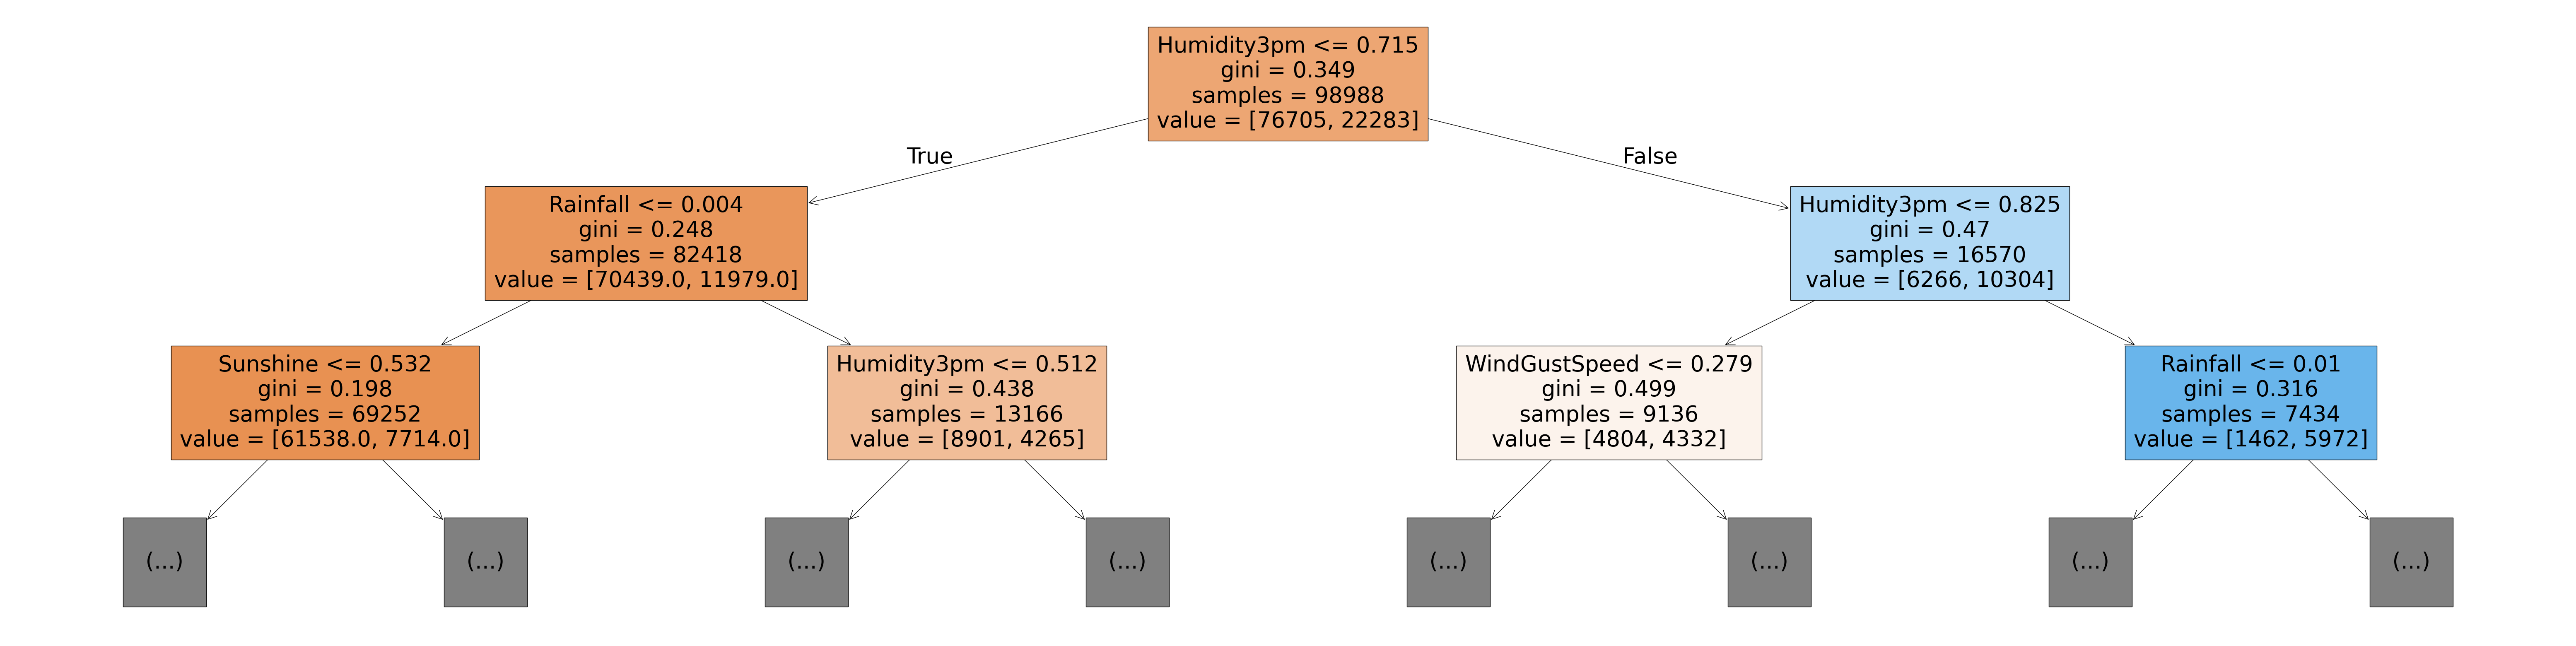

In [40]:
plt.figure(figsize=(80,20))
plot_tree(model,feature_names=x_train.columns,filled=True,max_depth=2);

In [41]:
model.tree_.max_depth

48

In [42]:
tree_text=export_text(model,max_depth=10,feature_names=list(x_train.columns))
print(tree_text[:5000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.57
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.44
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

In [43]:
model.feature_importances_

array([3.48942086e-02, 3.23605486e-02, 5.91385668e-02, 2.49619907e-02,
       4.94652143e-02, 5.63334673e-02, 2.80205998e-02, 2.98128801e-02,
       4.02182908e-02, 2.61441297e-01, 3.44145027e-02, 6.20573699e-02,
       1.36406176e-02, 1.69229866e-02, 3.50001550e-02, 3.04064076e-02,
       2.24086587e-03, 2.08018104e-03, 1.27475954e-03, 7.26936324e-04,
       1.39779517e-03, 1.15264873e-03, 6.92808159e-04, 1.80675598e-03,
       1.08370901e-03, 1.19773895e-03, 8.87119103e-04, 2.15764220e-03,
       1.67094731e-03, 7.98919493e-05, 1.10558668e-03, 1.42008656e-03,
       4.10087635e-04, 1.09028115e-03, 1.44164766e-03, 9.08284767e-04,
       1.05770304e-03, 6.18133455e-04, 1.80387272e-03, 2.10403527e-03,
       2.74413333e-04, 7.31599405e-04, 1.35408990e-03, 1.54759332e-03,
       1.30917564e-03, 1.07134670e-03, 8.36408023e-04, 1.62662229e-03,
       1.00326116e-03, 2.16053455e-03, 8.46802258e-04, 1.88919081e-03,
       9.29325203e-04, 1.29545157e-03, 1.27604831e-03, 5.12736888e-04,
      

In [44]:
importance_df = pd.DataFrame({'feature name':x_train.columns,'importance':model.feature_importances_}).sort_values('importance',ascending=False)
importance_df.head(10)

,feature name,importance
9,Humidity3pm,0.261441
11,Pressure3pm,0.062057
2,Rainfall,0.059139
5,WindGustSpeed,0.056333
4,Sunshine,0.049465
8,Humidity9am,0.040218
14,Temp9am,0.035000
0,MinTemp,0.034894
10,Pressure9am,0.034415
1,MaxTemp,0.032361


<Axes: xlabel='importance', ylabel='feature name'>

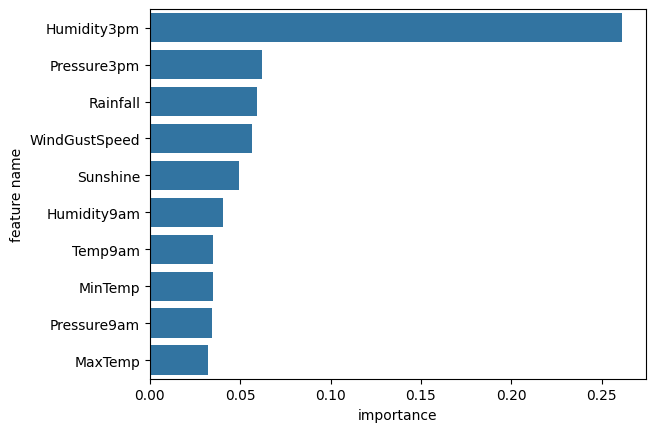

In [45]:
sns.barplot(data=importance_df.head(10),x='importance',y='feature name')

In [52]:
model = DecisionTreeClassifier(max_depth=7,random_state=42).fit(x_train,train_target)

In [53]:
model.score(x_val,val_target)

0.8449886831872787

In [54]:
model.score(x_train,train_target)

0.8466884874934335

In [49]:
def max_depth_error(md):
    model=DecisionTreeClassifier(max_depth=md,random_state=42)
    model.fit(x_train,train_target)
    train_acc = 1-model.score(x_train,train_target)
    val_acc = 1-model.score(x_val,val_target)
    return {'max_depth':md,'train_accuracy':train_acc,'validation_acc':val_acc}

In [50]:
test_df = pd.DataFrame([max_depth_error(md) for md in range(1,21)])

In [51]:
test_df

,max_depth,train_accuracy,validation_acc
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164413
4,5,0.160676,0.158784
5,6,0.156271,0.158435
6,7,0.153312,0.155011
7,8,0.147806,0.161801
8,9,0.140906,0.162556
9,10,0.132945,0.163310


# RANDOM FOREST

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
model = RandomForestClassifier(n_jobs=-1,random_state=42).fit(x_train,train_target)

In [63]:
model.score(x_val,val_target)

0.8563054959085369

In [65]:
model.predict_proba(x_val)

array([[0.98, 0.02],
       [0.85, 0.15],
       [0.91, 0.09],
       ...,
       [0.91, 0.09],
       [0.88, 0.12],
       [0.84, 0.16]], shape=(17231, 2))

In [71]:
len(model.estimators_)

100

In [72]:
importance_df=pd.DataFrame({
    'features':x_train.columns,
    'importance':model.feature_importances_
}).sort_values('importance',ascending=False)

In [74]:
importance_df.head(10)

,features,importance
9,Humidity3pm,0.139904
4,Sunshine,0.053696
11,Pressure3pm,0.052713
8,Humidity9am,0.050051
2,Rainfall,0.048077
10,Pressure9am,0.047944
5,WindGustSpeed,0.047477
15,Temp3pm,0.044379
1,MaxTemp,0.041865
0,MinTemp,0.041199


In [76]:
train_acc = model.score(x_train,train_target)
val_acc = model.score(x_val,val_target)
base_model = train_acc,val_acc
base_model

(0.9999494888269285, 0.8563054959085369)

In [116]:
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [98]:
def try_params(**params):
    model=RandomForestClassifier(n_jobs=-1,random_state=42,**params).fit(x_train,train_target)
    return pd.DataFrame({
        'new_model':(model.score(x_train,train_target),model.score(x_val,val_target)),'base_model':base_model},index=['train','val'])

In [99]:
try_params(n_estimators=20)

,new_model,base_model
train,0.996262,0.999949
val,0.851373,0.856305


In [100]:
try_params(n_estimators=50)

,new_model,base_model
train,0.999657,0.999949
val,0.854739,0.856305


In [138]:
try_params(n_estimators=500)

,new_model,base_model
train,0.999980,0.999949
val,0.855783,0.856305


In [104]:
try_params(max_features='log2')

,new_model,base_model
train,0.999960,0.999949
val,0.852649,0.856305


In [142]:
try_params(max_features=20)

,new_model,base_model
train,0.999960,0.999949
val,0.854564,0.856305


In [145]:
try_params(max_features=9)

,new_model,base_model
train,0.999960,0.999949
val,0.855087,0.856305


In [110]:
try_params(max_depth=3)

,new_model,base_model
train,0.793854,0.999949
val,0.802855,0.856305


In [113]:
try_params(max_depth=25)

,new_model,base_model
train,0.977563,0.999949
val,0.854158,0.856305


In [114]:
try_params(max_leaf_nodes=124)

,new_model,base_model
train,0.845446,0.999949
val,0.842609,0.856305


In [115]:
try_params(max_leaf_nodes=2**10)

,new_model,base_model
train,0.877692,0.999949
val,0.850908,0.856305


In [117]:
try_params(min_samples_split=3,min_samples_leaf=2)

,new_model,base_model
train,0.962480,0.999949
val,0.853404,0.856305


In [119]:
try_params(min_samples_split=2,min_samples_leaf=3)

,new_model,base_model
train,0.933305,0.999949
val,0.853404,0.856305


In [121]:
try_params(min_impurity_decrease=1e-6)

,new_model,base_model
train,0.988817,0.999949
val,0.854216,0.856305


In [122]:
try_params(bootstrap=False)

,new_model,base_model
train,0.999980,0.999949
val,0.857756,0.856305


In [124]:
try_params(max_samples=0.8)

,new_model,base_model
train,0.998939,0.999949
val,0.854739,0.856305


In [125]:
try_params(max_samples=0.9)

,new_model,base_model
train,0.999768,0.999949
val,0.855203,0.856305


In [126]:
try_params(class_weight='balanced')

,new_model,base_model
train,0.999960,0.999949
val,0.852765,0.856305


In [127]:
try_params(class_weight={'No':1,'Yes':2})

,new_model,base_model
train,0.999960,0.999949
val,0.856015,0.856305


In [129]:
try_params(class_weight={'No':2,'Yes':3})

,new_model,base_model
train,0.999949,0.999949
val,0.854100,0.856305


In [158]:
model=RandomForestClassifier(n_jobs=-1,
                            random_state=42,
                            n_estimators=500,
                            max_features=10,
                            max_depth=20,
                            class_weight={'No':1,'Yes':1.5})

In [159]:
model.fit(x_train,train_target)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [160]:
model.score(x_val,val_target)

0.85694388021589

In [161]:
base_model

(0.9999494888269285, 0.8563054959085369)

In [162]:
model.score(x_test,test_target)

0.8410718410718411